# Prodigy Excel Pivot Tables and Charts - Python (pandas) Companion Notebook

**Prodigy Training Hub | Trainer: Kajola Gbenga Adewale**

This notebook reproduces every Pivot Table and Pivot Chart exercise from the companion Word document
(*Prodigy Excel Pivot Tables and Charts - Training Guide*) using `pandas` and `matplotlib`.

Purpose:
- Verify the model answers given in the Word document (the numbers match exactly).
- Show learners the pandas equivalent of each Excel Pivot Table operation - useful when they progress
  from Excel to Python for data analysis.
- Provide instructors with a reusable answer key that recalculates automatically if the dataset changes.

Dataset: `retail_dataset.csv` - Prodigy Retail & Electronics Ltd, Nigeria sales records (2023-2025).

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 10

df = pd.read_csv("retail_dataset.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])

print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

ERROR! Session/line number was not unique in database. History logging moved to new session 537
Rows: 1,100   Columns: 28


,Order ID,Order Date,Year,Quarter,Month,Region,State,City,Branch,Sales Rep,...,Discount Amount (NGN),Net Sales (NGN),Unit Cost (NGN),Total Cost (NGN),Profit (NGN),Profit Margin %,Payment Method,Order Status,Delivery Days,Customer Rating (1-5)
0,PRD-100001,2023-01-01,2023,Q1,January,North West,Kaduna,Zaria,Zaria Outlet,Ahmed Bello,...,"64,470.00","1,224,930.00","168,800.00","1,012,800.00","212,130.00",17.32,Cash,Completed,9,5
1,PRD-100002,2023-01-01,2023,Q1,January,South West,Ogun,Sagamu,Sagamu Outlet,Amaka Nwosu,...,0.00,"751,200.00","71,100.00","568,800.00","182,400.00",24.28,POS,Returned,5,3
2,PRD-100003,2023-01-02,2023,Q1,January,South South,Delta,Warri,Warri Outlet,Emeka Chukwu,...,"13,560.00","122,040.00","29,200.00","87,600.00","34,440.00",28.22,Bank Transfer,Completed,8,4
3,PRD-100004,2023-01-07,2023,Q1,January,North West,Kaduna,Kaduna City,Kaduna Outlet,Ahmed Bello,...,0.00,"199,100.00","155,200.00","155,200.00","43,900.00",22.05,Card,Completed,9,5
4,PRD-100005,2023-01-13,2023,Q1,January,North Central,Niger,Minna,Minna Outlet,Musa Ibrahim,...,"6,420.00","121,980.00","13,100.00","78,600.00","43,380.00",35.56,Bank Transfer,Completed,10,5


## Pivot Table 1: Total Net Sales by Region

**Excel equivalent:** Rows = Region, Values = Sum of Net Sales (NGN).

This mirrors dragging **Region** into the Rows area and **Net Sales (NGN)** into the Values area of a
Pivot Table, then sorting largest to smallest.

In [9]:
pt1 = df.groupby("Region")["Net Sales (NGN)"].sum().sort_values(ascending=False)
pt1_display = pt1.map(lambda x: f"N{x:,.0f}")
pt1_display

Region
South West       N191,418,345
South South      N111,146,465
South East       N107,611,860
North West       N106,240,460
North Central    N103,460,235
North East        N42,360,805
Name: Net Sales (NGN), dtype: object

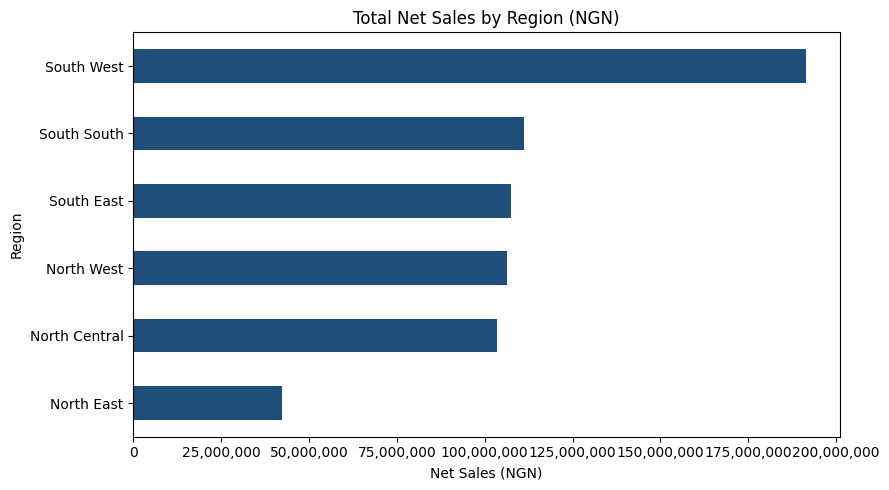

In [10]:
ax = pt1.sort_values().plot(kind="barh", color="#1F4E78")
ax.set_title("Total Net Sales by Region (NGN)")
ax.set_xlabel("Net Sales (NGN)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## Pivot Table 2: Net Sales by Product Category and Region (Matrix)

**Excel equivalent:** Rows = Product Category, Columns = Region, Values = Sum of Net Sales (NGN).

In [11]:
pt2 = df.pivot_table(index="Product Category", columns="Region",
                      values="Net Sales (NGN)", aggfunc="sum", fill_value=0)
pt2.style.format("N{:,.0f}")

Region,North Central,North East,North West,South East,South South,South West
Product Category,,,,,,
Computing,"N27,426,360","N2,776,015","N45,609,600","N32,874,165","N34,109,505","N62,700,690"
Electronics,"N15,495,615","N5,962,890","N19,202,395","N21,132,365","N16,861,855","N39,125,000"
Fashion & Accessories,"N2,301,745","N897,555","N2,519,185","N5,440,930","N1,861,270","N4,705,020"
Furniture,"N12,684,290","N15,324,100","N16,447,805","N15,303,400","N14,744,740","N27,729,165"
Home Appliances,"N17,804,415","N5,680,230","N8,363,685","N17,098,215","N16,740,215","N24,765,195"
Phones & Tablets,"N27,747,810","N11,720,015","N14,097,790","N15,762,785","N26,828,880","N32,393,275"


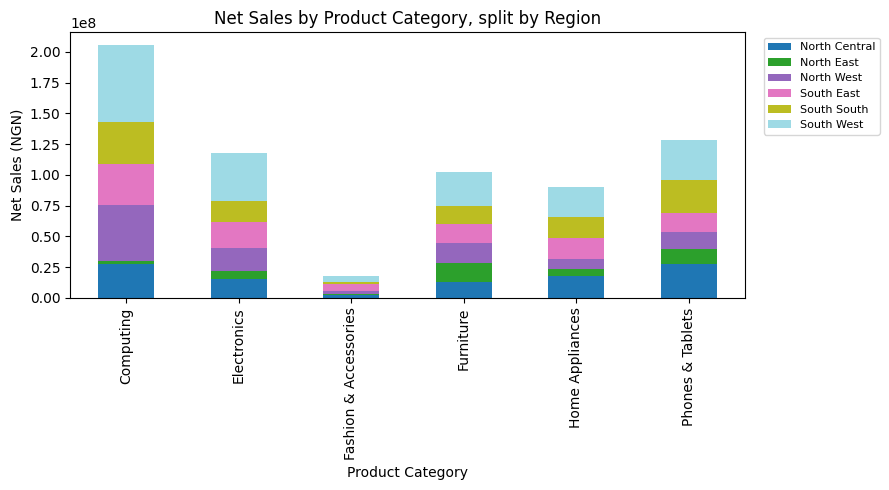

In [12]:
pt2.plot(kind="bar", stacked=True, colormap="tab20")
plt.title("Net Sales by Product Category, split by Region")
plt.ylabel("Net Sales (NGN)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Pivot Table 3: Sales Rep Performance (Orders, Average Order Value, Total Sales)

**Excel equivalent:** Rows = Sales Rep, Values = Count of Order ID, Average of Net Sales (NGN),
Sum of Net Sales (NGN). Sorted by Total Sales descending, Top 5 shown.

In [13]:
pt3 = df.groupby("Sales Rep").agg(
    Orders=("Order ID", "count"),
    Avg_Order_Value=("Net Sales (NGN)", "mean"),
    Total_Net_Sales=("Net Sales (NGN)", "sum"),
).sort_values("Total_Net_Sales", ascending=False)

pt3_top5 = pt3.head(5).copy()
pt3_top5["Avg_Order_Value"] = pt3_top5["Avg_Order_Value"].map(lambda x: f"N{x:,.0f}")
pt3_top5["Total_Net_Sales"] = pt3_top5["Total_Net_Sales"].map(lambda x: f"N{x:,.0f}")
pt3_top5

,Orders,Avg_Order_Value,Total_Net_Sales
Sales Rep,,,
Ahmed Bello,73,"N858,983","N62,705,725"
Zainab Aliyu,95,"N626,958","N59,561,050"
Kunle Adebayo,84,"N676,044","N56,787,730"
Tunde Bakare,65,"N817,609","N53,144,595"
Bimbo Ogundipe,83,"N581,392","N48,255,500"


## Pivot Table 4: Quarterly Sales Trend

**Excel equivalent:** Rows = Year then Quarter, Values = Sum of Net Sales (NGN). Used to build a
Pivot Chart (Line Chart) showing the sales trend over the three-year period.

In [14]:
pt4 = df.groupby(["Year", "Quarter"])["Net Sales (NGN)"].sum().reset_index()
pt4["Period"] = pt4["Year"].astype(str) + " " + pt4["Quarter"]
pt4_display = pt4.set_index("Period")["Net Sales (NGN)"].map(lambda x: f"N{x:,.0f}")
pt4_display

Period
2023 Q1    N54,237,305
2023 Q2    N49,259,465
2023 Q3    N52,704,135
2023 Q4    N60,750,950
2024 Q1    N75,574,800
2024 Q2    N39,711,165
2024 Q3    N60,020,195
2024 Q4    N51,826,075
2025 Q1    N70,481,785
2025 Q2    N46,081,635
2025 Q3    N56,646,445
2025 Q4    N44,944,215
Name: Net Sales (NGN), dtype: object

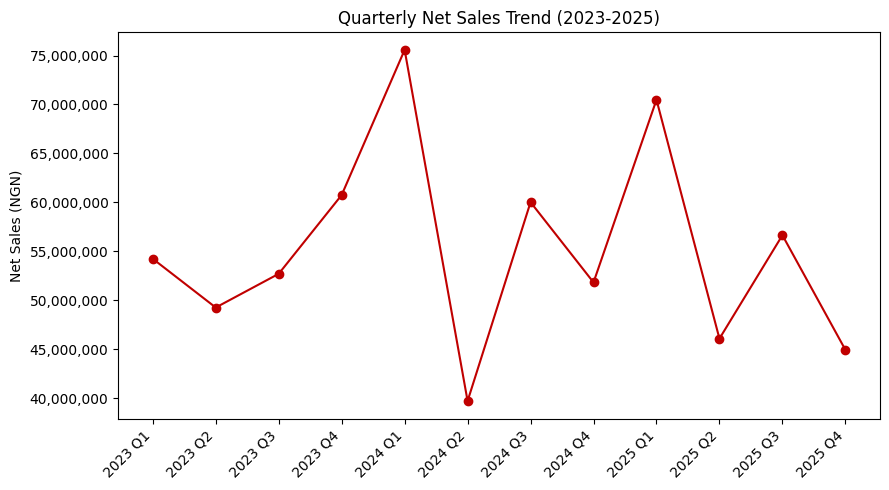

In [15]:
plt.plot(pt4["Period"], pt4["Net Sales (NGN)"], marker="o", color="#C00000")
plt.xticks(rotation=45, ha="right")
plt.title("Quarterly Net Sales Trend (2023-2025)")
plt.ylabel("Net Sales (NGN)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## Pivot Table 5: Profit Margin Analysis by Product Category

**Excel equivalent:** Rows = Product Category, Values = Sum of Net Sales, Sum of Profit, plus a
calculated field Profit Margin % = Sum of Profit / Sum of Net Sales.

In [16]:
pt5 = df.groupby("Product Category").agg(
    Net_Sales=("Net Sales (NGN)", "sum"),
    Profit=("Profit (NGN)", "sum"),
)
pt5["Margin_%"] = (pt5["Profit"] / pt5["Net_Sales"] * 100).round(2)
pt5_sorted = pt5.sort_values("Margin_%", ascending=False)
pt5_display = pt5_sorted.copy()
pt5_display["Net_Sales"] = pt5_display["Net_Sales"].map(lambda x: f"N{x:,.0f}")
pt5_display["Profit"] = pt5_display["Profit"].map(lambda x: f"N{x:,.0f}")
pt5_display

,Net_Sales,Profit,Margin_%
Product Category,,,
Fashion & Accessories,"N17,725,705","N5,883,005",33.19
Furniture,"N102,233,500","N19,867,600",19.43
Home Appliances,"N90,451,955","N16,736,955",18.50
Electronics,"N117,780,120","N21,557,120",18.30
Phones & Tablets,"N128,550,555","N19,757,755",15.37
Computing,"N205,496,335","N28,428,535",13.83


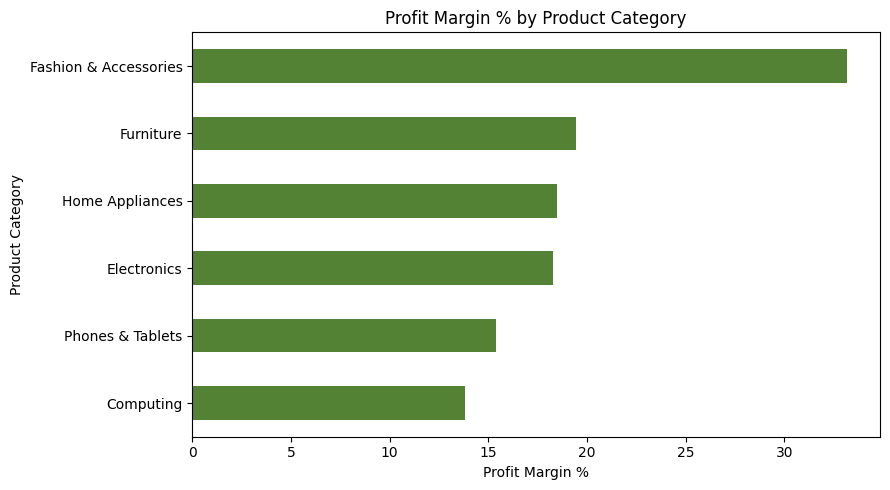

In [17]:
ax = pt5_sorted["Margin_%"].sort_values().plot(kind="barh", color="#548235")
ax.set_title("Profit Margin % by Product Category")
ax.set_xlabel("Profit Margin %")
plt.tight_layout()
plt.show()

## Pivot Table 6: Payment Method Distribution

**Excel equivalent:** Rows = Payment Method, Values = Count of Order ID, shown as % of Column Total
(right-click Value Field Settings > Show Values As > % of Column Total).

In [18]:
pt6 = df["Payment Method"].value_counts()
pt6_pct = (pt6 / pt6.sum() * 100).round(1)
pt6_table = pd.DataFrame({"Orders": pt6, "Percent of Total": pt6_pct.map(lambda x: f"{x}%")})
pt6_table

,Orders,Percent of Total
Payment Method,,
POS,323,29.4%
Bank Transfer,323,29.4%
Card,201,18.3%
Cash,177,16.1%
USSD,76,6.9%


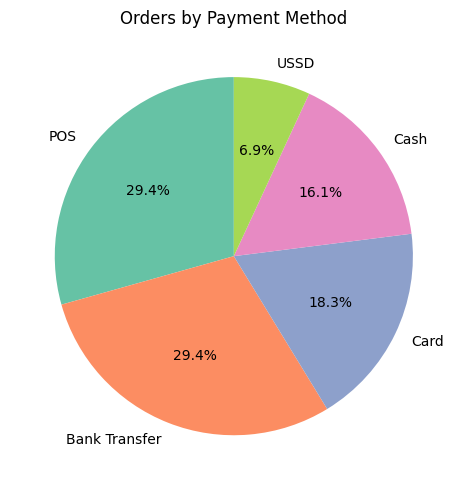

In [19]:
plt.pie(pt6, labels=pt6.index, autopct="%1.1f%%", colors=plt.cm.Set2.colors, startangle=90)
plt.title("Orders by Payment Method")
plt.tight_layout()
plt.show()

## Pivot Table 7: Order Status Breakdown (Returned / Cancelled Impact)

**Excel equivalent:** Rows = Order Status, Values = Count of Order ID, Sum of Net Sales (NGN).
Used to quantify revenue at risk from Returned and Cancelled orders.

In [20]:
pt7 = df.groupby("Order Status").agg(
    Orders=("Order ID", "count"),
    Net_Sales=("Net Sales (NGN)", "sum"),
)
pt7_display = pt7.copy()
pt7_display["Net_Sales"] = pt7_display["Net_Sales"].map(lambda x: f"N{x:,.0f}")
pt7_display

,Orders,Net_Sales
Order Status,,
Cancelled,196,"N122,887,105"
Completed,731,"N426,161,225"
Returned,173,"N113,189,840"


In [21]:
total_orders = len(df)
rc = df[df["Order Status"].isin(["Returned", "Cancelled"])]
rc_pct = len(rc) / total_orders * 100
rc_value = rc["Net Sales (NGN)"].sum()
print(f"Returned + Cancelled orders: {len(rc)} of {total_orders} ({rc_pct:.1f}%)")
print(f"Net Sales value tied up in Returned + Cancelled orders: N{rc_value:,.0f}")

Returned + Cancelled orders: 369 of 1100 (33.5%)
Net Sales value tied up in Returned + Cancelled orders: N236,076,945


## Pivot Table 8: Top 10 Products by Net Sales

**Excel equivalent:** Rows = Product Name, Values = Sum of Net Sales (NGN), then Value Filter >
Top 10 (or manually sort and keep the first 10 rows).

In [22]:
pt8 = df.groupby("Product Name")["Net Sales (NGN)"].sum().sort_values(ascending=False).head(10)
pt8_display = pt8.map(lambda x: f"N{x:,.0f}")
pt8_display

Product Name
MacBook Air M2                 N81,546,480
LG 55-inch OLED TV             N57,959,865
Lenovo ThinkPad E14            N47,978,375
iPhone 15                      N43,574,440
Dell Inspiron 14               N42,051,485
HP Pavilion 15                 N28,591,085
4-Seater Office Workstation    N27,406,145
6-Seater Dining Set            N26,548,380
Samsung Double Door Fridge     N25,698,360
Samsung 43-inch Smart TV       N22,490,360
Name: Net Sales (NGN), dtype: object

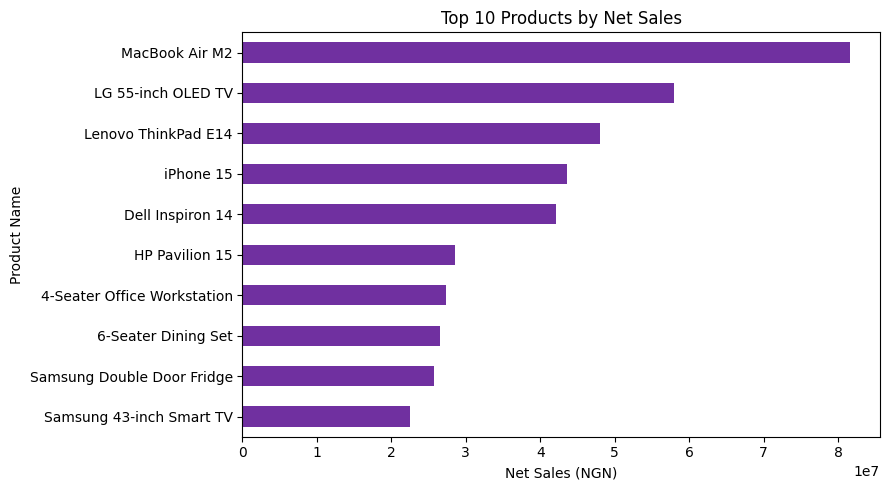

In [23]:
ax = pt8.sort_values().plot(kind="barh", color="#7030A0")
ax.set_title("Top 10 Products by Net Sales")
ax.set_xlabel("Net Sales (NGN)")
plt.tight_layout()
plt.show()

## Pivot Table 9: Customer Segment Analysis

**Excel equivalent:** Rows = Customer Segment, Values = Count of Order ID, Average of Customer
Rating (1-5), Sum of Net Sales (NGN).

In [24]:
pt9 = df.groupby("Customer Segment").agg(
    Orders=("Order ID", "count"),
    Avg_Rating=("Customer Rating (1-5)", "mean"),
    Net_Sales=("Net Sales (NGN)", "sum"),
).sort_values("Net_Sales", ascending=False)
pt9_display = pt9.copy()
pt9_display["Avg_Rating"] = pt9_display["Avg_Rating"].round(2)
pt9_display["Net_Sales"] = pt9_display["Net_Sales"].map(lambda x: f"N{x:,.0f}")
pt9_display

,Orders,Avg_Rating,Net_Sales
Customer Segment,,,
Retail,506,3.89,"N272,403,150"
Corporate,333,3.78,"N222,906,570"
Government,151,3.80,"N96,546,715"
Online,110,3.95,"N70,381,735"


## Pivot Table 10: Region x Payment Method Cross-Tab

**Excel equivalent:** Rows = Region, Columns = Payment Method, Values = Count of Order ID.
Used to build a 100% Stacked Column Pivot Chart comparing payment preferences across regions.

In [25]:
pt10 = df.pivot_table(index="Region", columns="Payment Method",
                       values="Order ID", aggfunc="count", fill_value=0)
pt10

Payment Method,Bank Transfer,Card,Cash,POS,USSD
Region,,,,,
North Central,55,34,30,54,8
North East,24,17,13,21,11
North West,46,30,25,38,7
South East,64,42,28,55,16
South South,44,25,32,61,11
South West,90,53,49,94,23


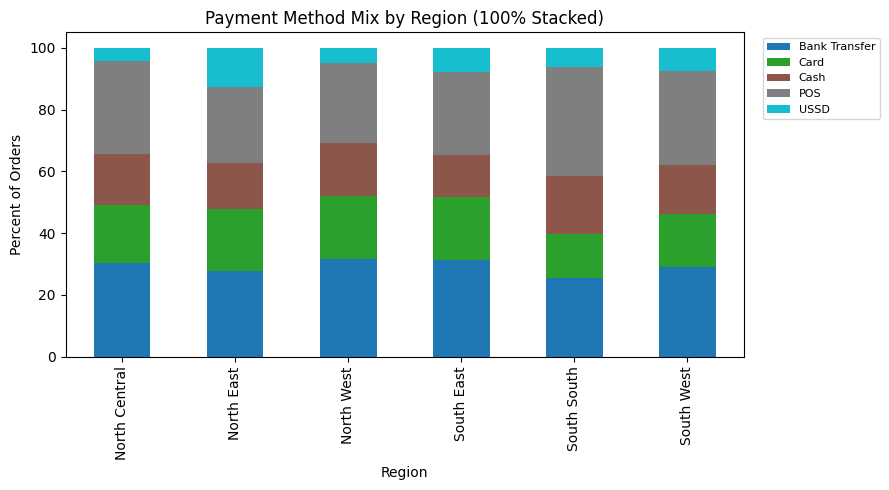

In [26]:
pt10_pct = pt10.div(pt10.sum(axis=1), axis=0) * 100
pt10_pct.plot(kind="bar", stacked=True, colormap="tab10")
plt.title("Payment Method Mix by Region (100% Stacked)")
plt.ylabel("Percent of Orders")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Summary

This notebook confirms the model answers used throughout the companion Word document. Instructors can
re-run all cells after adding new rows to `retail_dataset.csv` to regenerate an up-to-date answer key,
and learners moving from Excel to Python can compare each `groupby` / `pivot_table` call directly against
the equivalent Excel Pivot Table steps.

**Prodigy Training Hub | www.github.com/prodigy234**